In [1]:
import torch

size = 256

test_dataset = torch.load(f'./dim2d_nx{size}_N50_solver=exponax_nu0.000_t40.0_ntimepoints201_test_all_frames.pt', weights_only=False)

In [ ]:
import torch

size = 256

train_dataset = torch.load(f'./dim2d_nx{size}_N1150_solver=exponax_nu0.000_t40.0_ntimepoints201_train_all_frames.pt', weights_only=False)

In [4]:
import os
import matplotlib.pyplot as plt
from PIL import Image
import torch

def create_heatmap_gif(array1,  
                      title1='Heatmap 1', 
                      cmap='viridis', figsize=(6, 6),
                      colorbar=True, 
                      fps=10, dpi=100, text="training"):
    # Create temporary directory for frames
    os.makedirs('temp_frames', exist_ok=True)
    
    frame_files = []
    
    for idx in range(array1.shape[0]):
        fig, ax1 = plt.subplots(1, 1, figsize=figsize)
        
        # Plot first heatmap
        im1 = ax1.imshow(array1[idx], cmap=cmap, origin='lower')
        ax1.set_title(title1)
        ax1.set_xlabel('X')
        ax1.set_ylabel('Y')
        if colorbar:
            fig.colorbar(im1, ax=ax1, label='Value')
        
        plt.suptitle(f"Navier-Stokes Vorticity Transport (frame {idx+1}) ({text})")
        plt.tight_layout()
        
        # Save frame
        frame_file = f"temp_frames/frame_{idx:04d}.png"
        plt.savefig(frame_file, dpi=dpi, bbox_inches='tight')
        frame_files.append(frame_file)
        plt.close()
    
    # Create GIF from frames
    images = [Image.open(f) for f in frame_files]
    os.makedirs(f"gifs_nx{size}", exist_ok=True)
    images[0].save(f"gifs_nx{size}/{text}.gif", 
                  save_all=True, 
                  append_images=images[1:], 
                  duration=1000//fps, 
                  loop=0)
    
    # Clean up temporary files
    for f in frame_files:
        os.remove(f)
    os.rmdir('temp_frames')
    
    print(f"GIF saved as {text}.gif")

GIF saved as Dataset (exponax) comparison size=256 nt=40 idx=0.gif
GIF saved as Dataset (exponax) comparison size=256 nt=40 idx=1.gif
GIF saved as Dataset (exponax) comparison size=256 nt=40 idx=2.gif


KeyboardInterrupt: 

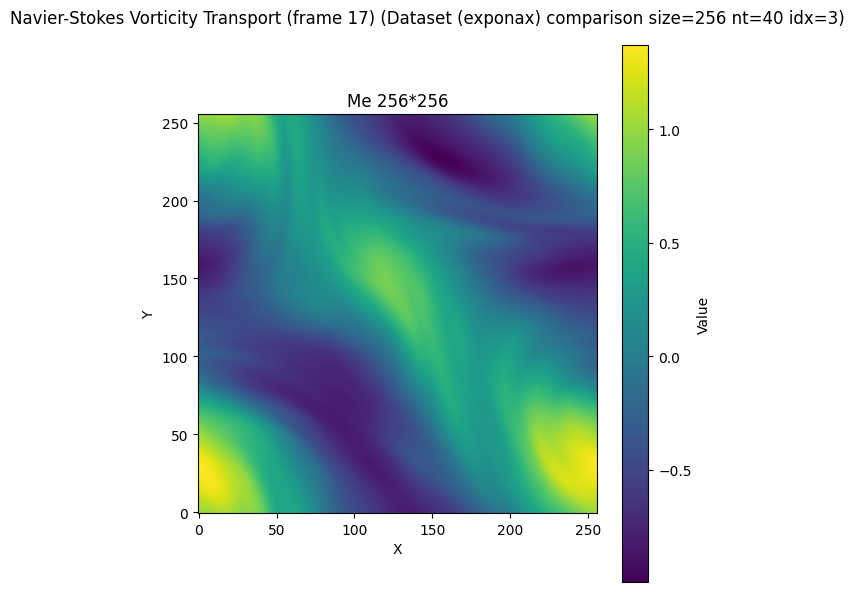

In [6]:
nt = 40
for idx in range(0,5):
    create_heatmap_gif(
        test_dataset["y"][idx].permute(2,1,0)[:-1], 
        title1=f'Me {size}*{size}',
        fps=10,
        text=f"Dataset (exponax) comparison size={size} nt={nt} idx={idx}"
    )

In [23]:
import torch
print("PyTorch version:", torch.__version__)
print("CUDA version:", torch.version.cuda)

PyTorch version: 2.7.0+cu126
CUDA version: 12.6


In [24]:
import torch
print(torch._C._cuda_getDeviceProperties(0).major, torch._C._cuda_getDeviceProperties(0).minor)

AttributeError: module 'torch._C' has no attribute '_cuda_getDeviceProperties'

In [25]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
name = torch.cuda.get_device_name(device)
capability = torch.cuda.get_device_capability(device)

print(f"Device name: {name}")
print(f"Compute capability (sm): {capability[0]}.{capability[1]}")

RuntimeError: Found no NVIDIA driver on your system. Please check that you have an NVIDIA GPU and installed a driver from http://www.nvidia.com/Download/index.aspx